---
title: Shallow Neural Networks
---

::: {.callout-tip}
## Slides
[Slides](https://docs.google.com/presentation/d/16tA4OMIaZcd1K1m4KHBcf5CYnqiCW85l62AnuUBzmfs/edit)
::: 

<!-- Open in Colab -->

<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/snn.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>




Shallow neural networks, like any other model, are simply functions $\boldsymbol{y = f_\phi[x]}$ with parameters $\boldsymbol{\phi}$ that map on or more inputs $x$ to one or more outputs $y$. 

Consider an example network $f[x, \phi]$ that maps a scalar input $x$ to a scalar output $y$ and has ten parameters $\phi = \{\phi_0, \phi_1, \phi_2, \phi_3, \theta_{10}, \theta_{11}, \theta_{20}, \theta_{21}, \theta_{30}, \theta_{31}\}$:

$$
\begin{aligned}
y
&= f[x,\boldsymbol{\phi}] \\ \\
&= \phi_0
 + \phi_1 a[\theta_{10}+\theta_{11}x]
 + \phi_2 a[\theta_{20}+\theta_{21}x]
 + \phi_3 a[\theta_{30}+\theta_{31}x].
\end{aligned}
\tag{1}
$$ 

We can break down this calculation into three parts:

1. First we compute three linear functions of the input data
    i. $\theta_{10} + \theta_{11}x$
    ii. $\theta_{20} + \theta_{21}x$
    iii. $\theta_{30} + \theta_{31}x$. 

2. Second, we pass the three results through an activation function a[•]. 

3. Finally,  
    i. we weight the three resulting activations with $\phi_1$, $\phi_2$, and $\phi_3$, \
    ii. sum them, and \
    iii. add an offset $\phi_0$.

The equations above yield a piecewise linear function with four linear regions. The following figure shows three examples of such piecewise linear functions, each with different choices of the ten parameters. 

<img src="assets/Chap03/ShallowFunctions.svg" style="filter: invert(1);" width="100%">

Family of functions defined by equation 3.1. a–c) Functions for three different ϕ. In each case, the input/output relation is piecewise linear. However, the positions of the joints, the slopes of the linear
regions between them, and the overall height vary.


To complete the description, we must define the activation function a[•].  There are many possibilities, but the most common choice is the rectified linear unit or ReLU:

$$
a[z]
=
\operatorname{ReLU}(z)
=
\begin{cases}
0, & z < 0, \\
z, & z \geq 0.
\end{cases}
\tag{2}
$$

<center><img src="assets/Chap03/ShallowReLU.svg" style="filter: invert(1);" width="50%" align="center"></center>

Rectified linear unit (ReLU) simply returns zero if the input is less than zero and returns the input unchanged otherwise. 

In other words, it clips negative values to zero. 

Note that there are many other possible choices for the activation function but the ReLU is one of the most commonly used and the easiest to understand.




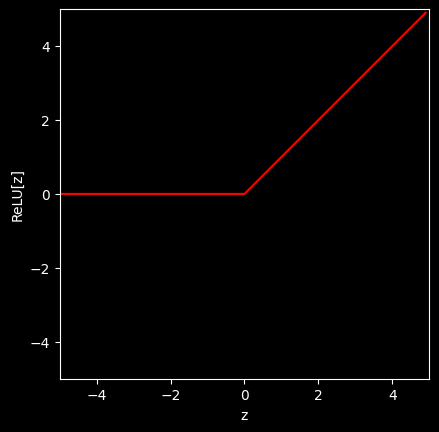

In [ ]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = [z if z >= 0 else 0 for z in preactivation]
  # Alternative implementation using numpy for better performance
  # activation = preactivation.clip(0, None)
  return activation

# Make an array of inputs
z = np.arange(-5,5,0.1)
RelU_z = ReLU(z)

# Plot the ReLU function
a = plt.plot(z,RelU_z,'r-')
plt.xlim([-5,5]);plt.ylim([-5,5])
plt.xlabel('z'); plt.ylabel('ReLU[z]')
# set aspect equal
plt.gca().set_aspect('equal', adjustable='box')

Now let's try to break down the computation of the equation (1), at the start of the page, into a series of steps.

<br>

### 1. Preactivations 

<br>

Pre-activations are the linear functions of the input data that are passed through the activation function. In this case, we have three pre-activations:

$$
\begin{aligned}
\theta_{10} + \theta_{11}x \\
\theta_{20} + \theta_{21}x \\
\theta_{30} + \theta_{31}x
\end{aligned}
$$


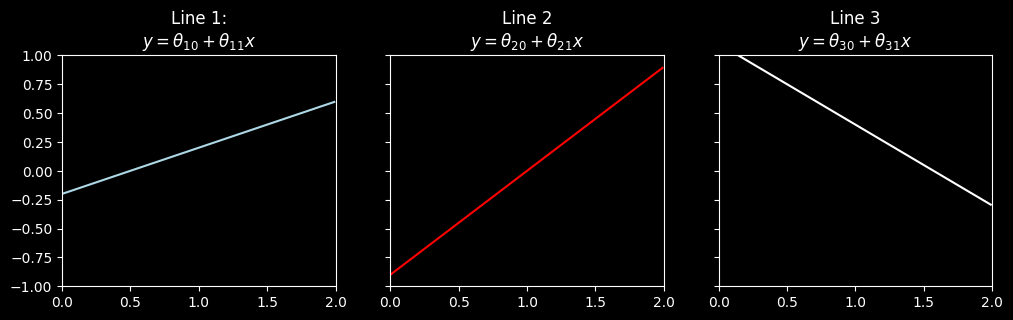

In [82]:

theta_10, theta_11 = -0.2,  0.4
theta_20, theta_21 = -0.9,  0.9
theta_30, theta_31 =  1.1, -0.7

# Now lets define some parameters and run the neural network
# theta_10 =  0.3 ; theta_11 = -1.0
# theta_20 = -1.0  ; theta_21 = 2.0
# theta_30 = -0.5  ; theta_31 = 0.65

# Define a range of input values
X = np.arange(0,2,0.01)


# X = np.arange(0,2,0.1)

preactivation_1 = theta_10 + theta_11 * X
preactivation_2 = theta_20 + theta_21 * X
preactivation_3 = theta_30 + theta_31 * X

fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=True)

plt.xlim(0, 2)
plt.ylim(-1, 1)

axs[0].plot(X, preactivation_1, c='lightblue');
axs[0].set_title('Line 1:\n$y = \\theta_{10} + \\theta_{11} x$')
axs[1].plot(X, preactivation_2, c='red');
axs[1].set_title('Line 2\n$y = \\theta_{20} + \\theta_{21} x$')
axs[2].plot(X, preactivation_3, c='white');
axs[2].set_title('Line 3\n$y = \\theta_{30} + \\theta_{31} x$');


<br>

### 2. Activations and Hidden Units 

<br>

The activations are the result of passing the pre-activations through the activation function. In this case, we have three activations:

$$
\begin{aligned}
h_1 = a[\theta_{10} + \theta_{11}x] \\
h_2 = a[\theta_{20} + \theta_{21}x] \\
h_3 = a[\theta_{30} + \theta_{31}x]
\end{aligned}
$$

$h_1$, $h_2$, and $h_3$ are called **hidden units**. They are "hidden" in the sense that they are internal, intermediate quantities computed by the network -- they are neither the input $x$ nor the final output $y$, and we never observe them directly in the training data (which only gives us $x$, $y$ pairs).

The number of hidden units is a design choice (a hyperparameter), not something learned from the data. Here we chose three hidden units, which is why the network has three pre-activations, three activations, and ten parameters in total. As we'll see below, each hidden unit contributes one "joint" to the piecewise linear function the network computes, so adding more hidden units gives the model more linear regions and hence more flexibility to represent complicated functions.

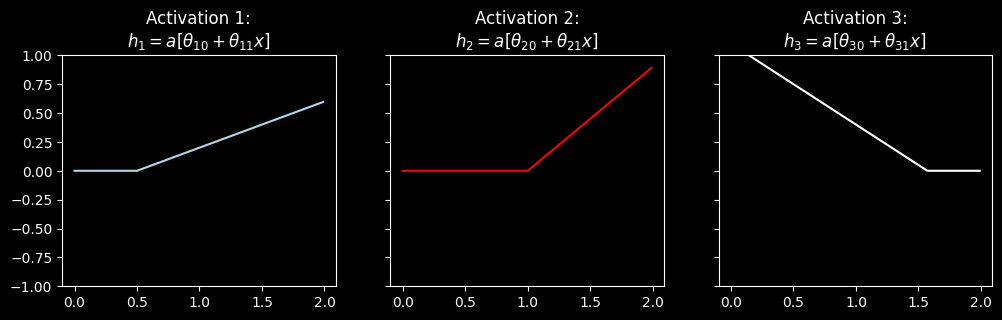

In [83]:

activation_1 = ReLU(preactivation_1)
activation_2 = ReLU(preactivation_2)
activation_3 = ReLU(preactivation_3)

fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=True)

plt.ylim([-1, 1]);

axs[0].plot(X, activation_1, c='lightblue');
axs[0].set_title('Activation 1:\n$h_1 = a[\\theta_{10} + \\theta_{11} x]$')

axs[1].plot(X, activation_2, c='red');
axs[1].set_title('Activation 2:\n$h_2 = a[\\theta_{20} + \\theta_{21} x]$')

axs[2].plot(X, activation_3, c='white');
axs[2].set_title('Activation 3:\n$h_3 = a[\\theta_{30} + \\theta_{31} x]$');


<br/>

### 3. Weighted Activations

<br/>

Activations are then weighted by the parameters $\phi_1$, $\phi_2$, and $\phi_3$:

$$
\begin{aligned}
\phi_1 h_1, \\
\phi_2 h_2, \\
\phi_3 h_3.
\end{aligned}
\tag{3}
$$

Note that when $h_i$ (or any other set of points for that matter) is multiplied with a scalar $\phi_i$, the effect is dependent on the sign and magnitude of $\phi_i$ 

* if $\phi_i \gt 1$, it stretches away from x-axis
* if $0 < \phi_i < 1$, it flattens towards the x-axis
* if $\phi_i \lt 0$, it reflects/flips across the x-axis. The magnitude of negative number dictates how much it stretches or flattens.  

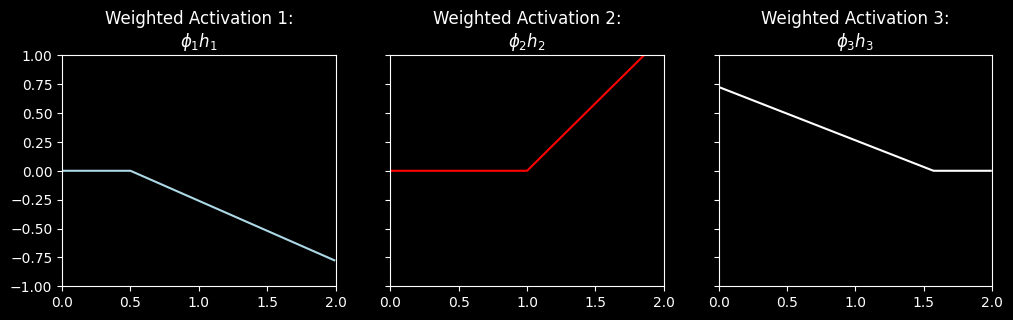

In [89]:
phi_1 = -1.3; phi_2 = 1.3; phi_3 = 0.66

weighted_activation_1 = phi_1 * np.array(activation_1)
weighted_activation_2 = phi_2 * np.array(activation_2)
weighted_activation_3 = phi_3 * np.array(activation_3)

fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=True)

plt.ylim([-1, 1]);
plt.xlim([0, 2]);

axs[0].plot(X, weighted_activation_1, c='lightblue');
axs[0].set_title('Weighted Activation 1:\n$\\phi_{1} h_1$')

axs[1].plot(X, weighted_activation_2, c='red');
axs[1].set_title('Weighted Activation 2:\n$\\phi_{2} h_2$')
axs[2].plot(X, weighted_activation_3, c='white');
axs[2].set_title('Weighted Activation 3:\n$\\phi_{3} h_3$');


<br>

### 4. Output

<br>

Finally, the weighted activations are summed and an offset $\phi_0$ is added to produce the output $y$:

$$
y = \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3.
\tag{4}
$$

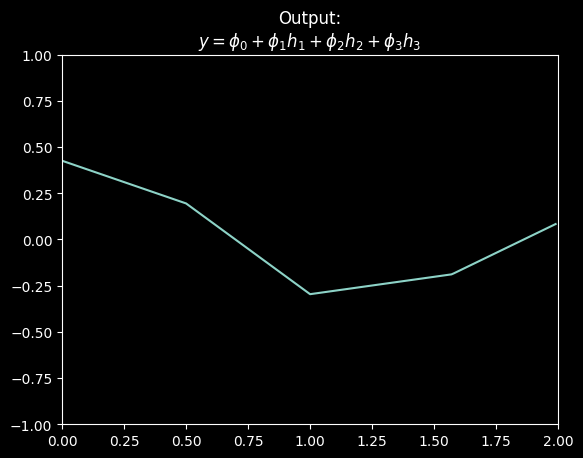

In [90]:
phi_0 = -0.3;

y = phi_0 + weighted_activation_1 + weighted_activation_2 + weighted_activation_3 

plt.plot(X, y);
plt.title('Output:\n$y = \\phi_{0} + \\phi_{1} h_1 + \\phi_{2} h_2 + \\phi_{3} h_3$')
plt.xlim([0, 2]); 
plt.ylim([-1, 1]);


### Summary

The following equations describe our example shallow neural network

$$
\begin{aligned}
h_1 &= a[\theta_{10}+\theta_{11}x], \\
h_2 &= a[\theta_{20}+\theta_{21}x], \\
h_3 &= a[\theta_{30}+\theta_{31}x].
\end{aligned}
\tag{1}
$$

$$
y
=
\phi_0+\phi_1h_1+\phi_2h_2+\phi_3h_3.
\tag{2}
$$

The figure below visualizes the flow of computation that results from the equations above. 

<img src="assets/Chap03/ShallowBuildUp.svg" style="filter: invert(1);" width="100%">

In summary, each hidden unit contains a linear function $\phi_0 + \phi_1 x$ (pre-activation) of the input called preactivation. 

Each line is clipped by the ReLU function a[•] below zero, giving us activations. 

The three clipped lines are then weighted by $\phi_1, \phi_2$, and $\phi_3$, respectively, and finally the offset $\phi_0$ is added, which controls the overall height of the final function.

An interactive version of the figure above is available at [Interactive figure](https://udlbook.github.io/udlfigures/) under "3.3a 1D shallow networks (ReLU)"


### Joints, Linear Regions and Activation Patterns

#### Joints and linear region:

A "joint" is a point where an activation function clips its preactivation -- i.e., where one of the three lines crosses zero. With three hidden units (three activation functions), there are up to three such joints in the final output. 

Between consecutive joints, the output is a straight line; these segments are called linear regions.

After clipping, the three lines are weighted by $\phi_1$, $\phi_2$, and $\phi_3$, respectively, and an offset $\phi_0$ is added, which controls the overall height of the final function.

#### Activation patterns:

Each linear region corresponds to a different activation pattern in the hidden units. 

A unit is inactive where its output is clipped to zero, and active where it is not. 

For example, the shaded region in figure 3.3j receives contributions from h1 and h3 (active) but not h2 (inactive).

The slope of a region is the sum of the weighted slopes θ•1ϕ• of its active hidden units -- e.g., the slope in the shaded region (see problem 3.3) is θ11ϕ1 + θ31ϕ3, combining the slope from panel (g) with the slope from panel (i).

#### Counting regions:

Each hidden unit contributes at most one joint, so three hidden units produce at most four linear regions. Only three of these four regions' slopes are independent, however: the fourth is either zero (if all hidden units are inactive there) or a sum of the other regions' slopes.

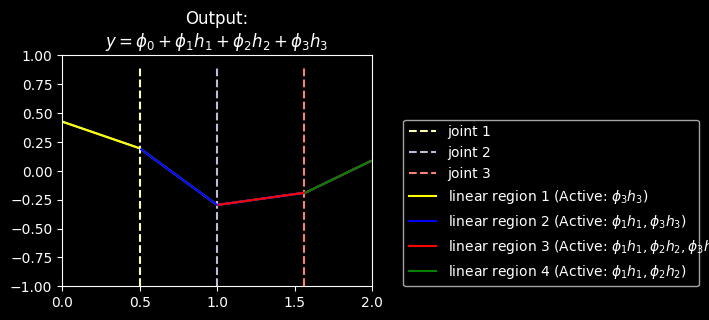

In [155]:
phi_0 = -0.3;

y = phi_0 + weighted_activation_1 + weighted_activation_2 + weighted_activation_3 

plt.figure(figsize=(4,3))
plt.plot(X, y);
plt.title('Output:\n$y = \\phi_{0} + \\phi_{1} h_1 + \\phi_{2} h_2 + \\phi_{3} h_3$')
plt.xlim([0, 2]); 
plt.ylim([-1, 1]);

plt.plot([0.5]*20,  np.arange(-1, 1, 0.1), '--', label='joint 1');
plt.plot([1]*20,    np.arange(-1, 1, 0.1), '--', label='joint 2');
plt.plot([1.56]*20, np.arange(-1, 1, 0.1), '--', label='joint 3');

plt.plot(X[X<0.5],  y[X<0.5], color='yellow',   label='linear region 1 (Active: $\phi_3 h_3$)') 
plt.plot(X[X>0.5],  y[X>0.5], color='blue',     label='linear region 2 (Active: $\phi_1 h_1, \phi_3 h_3$)') 
plt.plot(X[X>1],    y[X>1],   color='red',      label='linear region 3 (Active: $\phi_1 h_1, \phi_2 h_2, \phi_3 h_3$)');
plt.plot(X[X>1.56], y[X>1.56], color='green',   label='linear region 4 (Active: $\phi_1 h_1, \phi_2 h_2$)');

plt.legend(loc=(1.1, 0), mode="expand");


The figure above shows the same output function as before but with a breakdown of each of the four linear regions and highlighting each of the three joints. 

In the legend, in parentheses, activation patterns of each region shown. 



::: {.callout-important}

# Stop and Test your understanding

Manipulate the ten $\phi_k$ and $\theta_{ij}$ parameters (by hand!) to make the following model fit the data better. 

Try to reduce the loss to as small a number as possible.  The best that I could do was 0.181. 

Pro Tip: start by manipulating $\phi_0$. 

It's not that easy, so don't spend too all day on this!

<details><summary>Code to copy paste in Colab</summary>



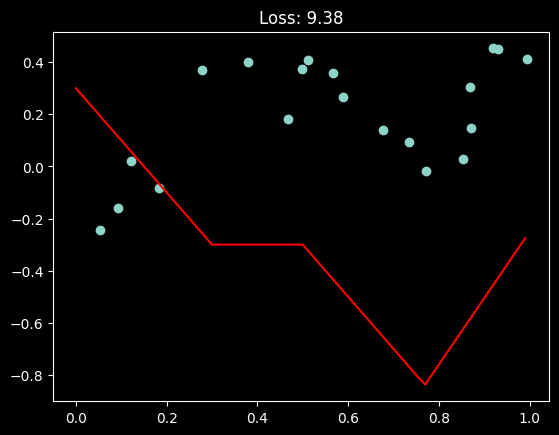

In [ ]:
def least_squares_loss(y_train, y_predict):
    return sum((y_train-y_predict)**2)

x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

plt.scatter(x_train, y_train);

def shallow_1_1_3(x1, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11,\
                  theta_20, theta_21, theta_30, theta_31):
  
  pre_1 = theta_10 + theta_11 * x1 
  pre_2 = theta_20 + theta_21 * x1 
  pre_3 = theta_30 + theta_31 * x1 

  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  w_act_1 = phi_1 * np.array(act_1)
  w_act_2 = phi_2 * np.array(act_2)
  w_act_3 = phi_3 * np.array(act_3)

  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  return y

theta_10 =  0.3; theta_11 = -1.0;
theta_20 = -1.0; theta_21 = 2.00;
theta_30 = -0.5; theta_31 = 0.65;

phi_0    = -0.3; phi_1    = 2.00;    phi_2 = -1.0;   phi_3 = 7.0

x = np.arange(0,1,0.01)

y_hat       = shallow_1_1_3(x, ReLU,  phi_0, phi_1, phi_2, phi_3, \
                            theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
y_hat_train = shallow_1_1_3(x_train, ReLU,  phi_0, phi_1, phi_2, phi_3, \
                            theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

plt.plot(x, y_hat, c='red');

plt.title(f"Loss: {round(least_squares_loss(y_train, y_hat_train), 2)}" );

</details>
:::  

</details>



## Neural Networks depiction and terminology

We have been discussing a neural network with one input, one output, and three hidden
units. 

We visualize this network as shown below. 

<img src="assets/Chap03/ShallowNet.svg" style="filter: invert(1);" width="100%">

The input $x$ is on the left, the hidden units $h_1$, $h_2$, and $h_3$ in the center, and the output $y$ on the right. 

Computation flows from left to right. 

The input is used to compute the hidden units, which are combined to create the output. 

Each of the ten arrows represents a parameter (intercepts in blue and slopes in white). 

Each parameter multiplies its source and adds the result to its target. For example, we multiply the parameter $\phi_1$ by source $h_1$ and add it to $y$. 

We introduce additional nodes containing ones (blue circles) to incorporate the offsets into this scheme, so we multiply $ϕ_0$ by one (with no effect) and add it to $y$. 

ReLU functions are applied at the hidden units. 

More typically, the intercepts, ReLU functions, and parameter names are omitted; the simpler depiction in  panel b on the right represents the same network as the left panel. 

<br/>

<img src="assets/Chap03/ShallowTerminology.svg" style="filter: invert(1);" width="100%">

<br/>

We conclude this chapter by introducing some terminology. Regrettably, neural networks
have a lot of associated jargon. 

They are often referred to in terms of layers. 

The left of the figue above is the input layer, the center is the hidden layer, and to the right is the output layer. 

We would say that the network in the figure has one hidden layer containing
four hidden units. 

The hidden units themselves are sometimes referred to as neurons.

When we pass data through the network, the values of the inputs to the hidden layer
(i.e., before the ReLU functions are applied) are termed pre-activations. 

The values at the hidden layer (i.e., after the ReLU functions) are termed activations.

For historical reasons, any neural network with at least one hidden layer is also called
a multi-layer perceptron, or MLP for short.

Networks with one hidden layer (as described in this chapter) are sometimes referred to as shallow neural networks. Networks with multiple hidden layers (as described in the next chapter) are referred to as deep neural networks. 

Neural networks in which the connections form an acyclic graph (i.e., a graph with no loops, as in all the examples in this chapter) are referred to as feed-forward networks. If every element in one layer connects to every element in the next (as in all the examples in this chapter), the network is fully connected. These connections represent slope parameters in the underlying equations and are referred to as network weights. The offset parameters (not shown) are called biases.
